<a href="https://colab.research.google.com/github/sonky20/sonky/blob/master/2%EC%9D%BC%EC%B0%A8_%EB%94%A5%EB%9F%AC%EB%8B%9D%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as no
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import *

In [23]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [25]:
#데이터 불러오기
path = 'https://bit.ly/advertising_csv'
adv = pd.read_csv(path)
adv.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [26]:
# x, y 분할
target = 'Sales'
x = adv.drop(target, axis=1)
y = adv.loc[:, target]

# 학습/검증 데이터 분리
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=20)
print(type(x_train), type(x_val))

# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
print(type(x_train), type(x_val))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [29]:
# 텐서 변환
x_train_ts = torch.tensor(x_train, dtype=torch.float32)
y_train_ts = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
x_val_ts = torch.tensor(x_val, dtype=torch.float32)
y_val_ts = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

# 디바이스 할당
x_train_ts, y_train_ts = x_train_ts.to(device), y_train_ts.to(device)
x_val_ts, y_val_ts = x_val_ts.to(device), y_val_ts.to(device)

In [30]:
BATCH_SIZE = 32
train_ds = TensorDataset(x_train_ts, y_train_ts)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [31]:
in_features = x_train_ts.shape[1]
model = nn.Sequential(nn.Linear(in_features, 1), ).to(device)

In [32]:
loss_fn = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.01)

In [33]:
EPOCHS = 100
tr_loss_list, val_loss_list = [], []
# 1. 학습 데이터 반복 학습
for epoch in range(EPOCHS):
  model.train() # 모델 학습 모드
  total_loss = 0.0
  n_batch = 0

  # 2. 에포크마다 배치 단위 학습
  for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    # 3. 학습
    # 오차 순전파: 학습 데이터에서 오차 계산
    pred = model(x) # 모델에 x를 입력해 예측
    loss = loss_fn(pred, y) # 오차 계산

    # 오차 역전파: 오차로부터 가중치 업데이트
    optimizer.zero_grad() # 기울기(gradient) 초기화
    loss.backward() # 손실 함수를 기준으로 각 가중치의 기울기를 계산
    optimizer.step() #기울기를 기준으로 가중치 조정

    total_loss += loss.item()
    n_batch += 1

  # 에포크마다 학습 오차 집계
  tr_loss = total_loss / n_batch

  # 4. 검증
  model.eval() # 모델 평가/추론 모드
  with torch.no_grad():
    val_pred = model(x_val_ts);
    val_loss = loss_fn(val_pred, y_val_ts)

  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"EPoch {epoch + 1 : 4d} | train loss {tr_loss:.4f} | val loss {val_loss:.4f}")

EPoch    1 | train loss 238.9426 | val loss 248.7509
EPoch    2 | train loss 235.5134 | val loss 245.2641
EPoch    3 | train loss 232.0836 | val loss 241.8084
EPoch    4 | train loss 228.6366 | val loss 238.3983
EPoch    5 | train loss 225.3136 | val loss 235.0083
EPoch    6 | train loss 221.9531 | val loss 231.6619
EPoch    7 | train loss 218.7034 | val loss 228.3372
EPoch    8 | train loss 215.3735 | val loss 225.0759
EPoch    9 | train loss 212.2507 | val loss 221.8134
EPoch   10 | train loss 209.0291 | val loss 218.6058
EPoch   11 | train loss 205.8341 | val loss 215.4563
EPoch   12 | train loss 202.7612 | val loss 212.3267
EPoch   13 | train loss 199.7287 | val loss 209.2176
EPoch   14 | train loss 196.7096 | val loss 206.1422
EPoch   15 | train loss 193.6310 | val loss 203.1372
EPoch   16 | train loss 190.7079 | val loss 200.1510
EPoch   17 | train loss 187.7990 | val loss 197.1930
EPoch   18 | train loss 184.8960 | val loss 194.2773
EPoch   19 | train loss 182.0330 | val loss 19

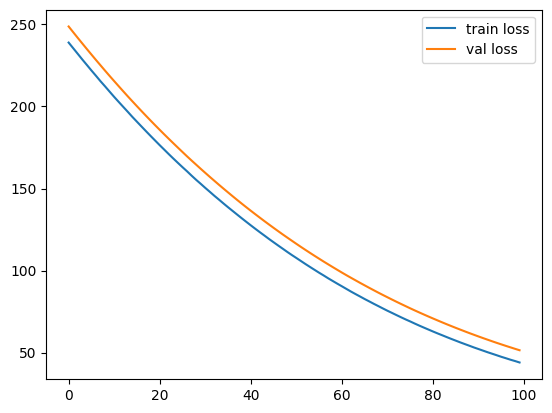

In [34]:
plt.plot(tr_loss_list, label='train loss')
plt.plot(val_loss_list, label='val loss')
plt.legend()
plt.show()

In [37]:
# 예측
model.eval()
with torch.no_grad():
  pred_val = model(x_val_ts).numpy()

true_val = y_val_ts.numpy()

# 평가
print(f"RMSE : {root_mean_squared_error(true_val, pred_val):.4f}")
print(f"MAE : {mean_absolute_error(true_val, pred_val):.4f}")
print(f"R2 Score : {r2_score(true_val, pred_val):.4f}")


RMSE : 7.1746
MAE : 6.0112
R2 Score : -0.4223
